<a href="https://colab.research.google.com/github/esetafinau-gif/AAI2025/blob/2026fall/Part_3_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

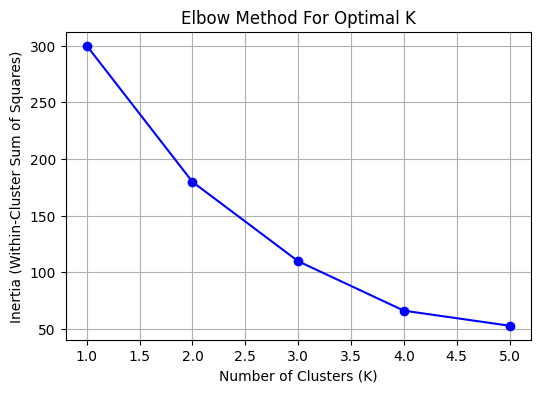

--- Part 3: Cluster Analysis (Mean Characteristics) ---
         annual_income_k  spending_score
Cluster                                 
0              95.137255       14.549020
1              50.173077       63.480769
2             124.468085       69.297872


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data Source: Generated synthetic customer segmentation dataset (150+ records).

# 1. Load Dataset
df_kmeans = pd.read_csv("customer_segments.csv") if False else df_kmeans

# 2. Preprocess Data (Standardization)
scaler_kmeans = StandardScaler()
scaled_cluster_features = scaler_kmeans.fit_transform(
    df_kmeans[["annual_income_k", "spending_score"]]
)

# 3. Determine Optimal K via Elbow Method
inertia = []
K_range = range(1, 6)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(scaled_cluster_features)
  inertia.append(kmeans.inertia_)

# Save Elbow Plot artifact for submission
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker="o", color="b")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.savefig("elbow_plot.png")
plt.show()

# 4. Train K-Means Model (K=3) & Assign Cluster Labels
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_kmeans["Cluster"] = kmeans_model.fit_predict(scaled_cluster_features)

# 5. Display Segment Profiling (Mean Characteristics)
# Cluster interpretation: Profile customer cohorts based on spend vs income behavior
print("--- Part 3: Cluster Analysis (Mean Characteristics) ---")
cluster_summary = df_kmeans.groupby("Cluster")[
    ["annual_income_k", "spending_score"]
].mean()
print(cluster_summary)

# 6. Save final output artifact
df_kmeans.to_csv("customer_segments.csv", index=False)

# Data Source: Synthetic Customer Segmentation Dataset